In [118]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm
from torch.utils.data import random_split
from torchmetrics.regression import MeanSquaredError
from matplotlib.gridspec import GridSpec


In [119]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

<h3>CMS pileup data compression based on VQ-VAE compression</h3>

Experiment comments and insights:
* Codebook entries from 256 vectors (rows), only approximately 120 codebook entries are used effectively based perplexity
* Reconstruction improves with bigger latent vector and num embeddings. Reducing codebook size, improves usage but not reconstruction quality
* Validation set properly works with higher beta coeficient roughly from beta in [0.2, 0.31]
* Codebook plots describe codebook variation, whether certain weights are mostly zero (grey color) and are codebook usage is not sparse (orange colors)

Utility function import and prepearation

In [120]:
from helpers.model_tool import ModelTool
from helpers.data_tool import CMSDataTool, \
                                CMSPlots, \
                                PixelPatchesDataset

<h3>Helper objects</h3>

In [121]:
model_tool = ModelTool()
cms_data_tool = CMSDataTool()
cms_plots = CMSPlots()

<h3>Helper constants</h3>

In [122]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
BITS_HIT = 25 
LOG_EVERY = 15

<h3>Data loading</h3>

In [123]:
# Loading data
pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:03<00:00, 272.02it/s]


<h3>VQ-VAE Hyperparameters</h3>

In [124]:
batch_size = 64
beta = 0.30
# beta = 0.98

# beta = 1 0.
# beta is possible in interval [4e-3, 8e-3]

# 0.1, 0.08 - on the right track

learning_rate = 1e-5
model_param_scale = 5
# model_param_scale = 1 (right order)
# learning_rate = 1e-3 (right on track)

num_epochs = 200
# num_epochs = 1

# input channels
channels = 1 # since grayscale images are used, we go with 1 channel images
hidden_channels = 64

# how many codebook entries
num_embeddings = 256
# num_embeddings = 32 (on track)

latent_dim = 32
# latent_dim = 64 (on track)

# Residual layer config
residual_channels = 32
residual_layers = 2

# Latent dimension size
d = 4 # adjustable encoder width for extra compression


In [125]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [126]:
mse = MeanSquaredError()
mse = mse.to(device)

In [127]:
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [128]:
event_train = events_train[:SELECTED_EVENTS][0]

In [129]:
patch_amount = cms_data_tool._get_patch_count(event_train)
total_hit_amount = len(event_train)

print(f"Total patch amount: {patch_amount}")
print(f"Total hits: {total_hit_amount}")

Total patch amount: 15857
Total hits: 48169


<h3>Data preprocessing</h3>

<h3>Data loading</h3>

In [130]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
])

event_dataset = PixelPatchesDataset(event_train, PATCH_SIZE, transform)
dataset_size = len(event_dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.02 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    event_dataset,
    [train_size, val_size, test_size]
)

# # Training data prepearation

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset, 
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=batch_size,
    shuffle=False
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 12685
Validation set size: 317
Test set size: 2855


<h3>VAE Binary Cross Entropy loss for VQ-VAE</h3>

In [131]:
def _get_vae_loss(
    recon_x: torch.tensor, 
    x: torch.tensor
) -> float:
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="mean")
    return recon_loss

<h3>VQ-VAE model</h3>

In [132]:
# Goal of Vector Quantization is to solve posterior collapse problem

class VectorQuantizer(nn.Module):
    """
    Discretization bottleneck part of the VQ-VAE.

    Inputs:
    - n_e : number of embeddings
    - e_dim : dimension of embedding
    - beta : commitment cost used in loss term, beta * ||z_e(x)-sg[e]||^2
    """

    def __init__(self, n_e, e_dim, beta):
        super(VectorQuantizer, self).__init__()
        self.n_e = n_e
        self.e_dim = e_dim
        self.beta = beta

        self.embedding = nn.Embedding(self.n_e, self.e_dim)
        self.embedding.weight.data.uniform_(-1.0 / self.n_e, 1.0 / self.n_e)

    def forward(self, z):
        """
        Inputs the output of the encoder network z and maps it to a discrete
        one-hot vector that is the index of the closest embedding vector e_j

        z (continuous) -> z_q (discrete)

        z.shape = (batch, channel, height, width)

        quantization pipeline:

            1. get encoder input (B,C,H,W)
            2. flatten input to (B*H*W,C)

        """
        # reshape z -> (batch, height, width, channel) and flatten
        z = z.permute(0, 2, 3, 1).contiguous()
        z_flattened = z.view(-1, self.e_dim)
        # distances from z to embeddings e_j (z - e)^2 = z^2 + e^2 - 2 e * z

        # NOTE: is a matrix learnable vector for learning codebook indices. 
        codebook = self.embedding.weight
        
        # Euclidean distance for finding closest codebooks
        d = torch.sum(z_flattened ** 2, dim=1, keepdim=True) + \
            torch.sum(self.embedding.weight**2, dim=1) - 2 * \
            torch.matmul(z_flattened, codebook.t())
            
        # Result -> d gets dimensions from matrix torch.matmul(z_flattened, self.embedding.weight.t())
        # embedding weight t is defined by num_embeddings, latent_dim
        # --------------------
            
        # find closest encodings
        min_encoding_indices = torch.argmin(d, dim=1).unsqueeze(1)
        min_encodings = torch.zeros(
            min_encoding_indices.shape[0], self.n_e).to(device)
        
        # perform one hot encoding
        min_encodings.scatter_(1, min_encoding_indices, 1)

        # NOTE: selects weights form embedding weight and puts them based on one hot encoding
        z_q = torch.matmul(min_encodings, codebook).view(z.shape)
        
        # beta - commitment cost used in loss term
        
        # compute loss for embedding
        loss = torch.mean((z_q.detach() - z)**2) + self.beta * \
            torch.mean((z_q - z.detach()) ** 2)

        # preserve gradients with preservation trick. Allows gradients to exist
        # (z_q - z.detach() )- is like a constant

        # We make quantized latent space vector to get closer to the encoder output
        # we highliht the codewords and gradually each epoch we force neaigoboring pixels
        # to be associating with cendroids
        z_q = z + (z_q - z).detach()

        # perplexity - average of weights of probabilities
        e_mean = torch.mean(min_encodings, dim=0)
        
        # Measures how many codebook vectors are beeing used
        perplexity = torch.exp(-torch.sum(e_mean * torch.log(e_mean + 1e-10)))

        # reshape back to match original input shape
        # contiguous() is used for improving performance
        z_q = z_q.permute(0, 3, 1, 2).contiguous()

        return loss, z_q, perplexity, min_encodings, min_encoding_indices, codebook

In [133]:
class ResidualLayer(nn.Module):
    """
    One residual layer inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    """

    def __init__(self, in_dim, h_dim, res_h_dim, slope):
        super(ResidualLayer, self).__init__()
        self.res_block = nn.Sequential(
            nn.LeakyReLU(negative_slope=slope, inplace=True),
            nn.Conv2d(in_dim, res_h_dim, kernel_size=3,
                      stride=1, padding=1, bias=False),
            nn.LeakyReLU(negative_slope=slope, inplace=True),
            nn.Conv2d(res_h_dim, h_dim, kernel_size=1,
                      stride=1, bias=False)
        )

    def forward(self, x):
        x = x + self.res_block(x)
        return x


class ResidualStack(nn.Module):
    """
    A stack of residual layers inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    - n_res_layers : number of layers to stack
    """

    def __init__(self, in_dim, h_dim, res_h_dim, n_res_layers, slope):
        super(ResidualStack, self).__init__()
        self.n_res_layers = n_res_layers
        self.slope = slope
        self.stack = nn.ModuleList(
            [
                ResidualLayer(in_dim, h_dim, res_h_dim, slope)
                for _ in range(n_res_layers)
            ])

    def forward(self, x):
        for layer in self.stack:
            x = layer(x)
        x = F.relu(x)
        return x

In [134]:
# TODO: think about it later
class AbstractModule(nn.Module):
    
    def __init__(self) -> None:
        super().__init__()
    
    def forward(self, x: torch.tensor) -> None:
        raise NotImplemented

In [135]:
# TODO: test with 2 x 2 encoded patch

class EncoderInput(AbstractModule):
    
    # NOTE: encoder_features - from convolution network
    
    def __init__(self, d: int, encoder_features: int = 2) -> None:
        super().__init__()
        
        self.latent_dim = latent_dim
        
        # TODO: in_features need to come from encoder conv network
        self.encoder_features = encoder_features
        self.layer = nn.Linear(in_features=encoder_features, out_features=d)
        
    def forward(self, x: torch.tensor) -> None:
        # x_3d = x.permute
        # 1. flatten to N x d 
        
        # 2. make linear transform
        
        # 3. transform back to 4d tensor
        
        # Would output work with VQ?
        # works if channel information is not lost
        b, c, _, _ = x.shape
        x_flatten = x.reshape(-1, self.encoder_features)
        enc_out = self.layer(x_flatten)
        enc_out = enc_out.view(-1, b, d, d)
        print(enc_out.shape)
        raise
        return enc_out
    

class DecoderInput(AbstractModule):
    
    # NOTE: decoder_features - required feature count for decoder
    
    def __init__(self, d: int, decoder_features: int = 2) -> None:
        super().__init__()
        
        self.latent_dim = latent_dim
        self.layer = nn.Linear(in_features=d, out_features=decoder_features)
        self.decoder_features = decoder_features
        
    def forward(self, x: torch.tensor) -> None:
        
        _, c, _, _ = x.shape
        x_flatten = x.reshape(-1, d)
        dec_out = self.layer(x_flatten)
        dec_out = dec_out.view(
            -1, c, 
            self.decoder_features, 
            self.decoder_features
        )
        return dec_out
    

In [136]:
# Comments
# kernel_size = 4 - preserves spatial repesentations (coordinates)
class VQVAE(nn.Module):
    
    def __init__(
        self, 
        hidden_channels: int, 
        kernel_size: int, 
        slope: float,
        res_h_dim: int,
        n_res_layers: int,
        d: int,
        residual_slope: float = 0.08,
    ) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(   
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),  
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),            
            nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=kernel_size-1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, latent_dim),
            ResidualStack(latent_dim, latent_dim, res_h_dim, n_res_layers, residual_slope)
        )
        
        # fully connected layer for encoder input
        self.fc_encoder_input = EncoderInput(d=d)     
        
        self.vq_layer = VectorQuantizer(num_embeddings, latent_dim, beta)
        
        # fully connected layer for vq input
        self.fc_decoder_input = DecoderInput(d=d)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            ResidualStack(hidden_channels * 2, hidden_channels * 2, res_h_dim, n_res_layers, residual_slope),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.Sigmoid()
        )

        
    def forward(self, x):
        encoder_output = self.encoder(x)
        z = self.fc_encoder_input(encoder_output)
        
        (
            recon_loss, 
            z_q, 
            perplexity, 
            min_encodings, 
            min_encoding_indices, 
            codebook
        ) = self.vq_layer(z)
        
        z_q = self.fc_decoder_input(z_q)
        
        output = self.decoder(z_q)
        
        return (
            output, 
            codebook, 
            z_q,
            perplexity, 
            recon_loss 
        )

In [137]:
model = VQVAE(
    hidden_channels=hidden_channels, 
    kernel_size = 4,
    slope=0.1,
    d=d,
    n_res_layers=residual_layers, # residual hidden layers
    res_h_dim=residual_channels # residual hidden channels
).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

<h3>VQ-VAE training loop</h3>

In [138]:
# BCE loss average values
average_loss_train = []
average_loss_values_val = []
average_loss_train_bce = []

# Patches (validation)
patches_before_val = []
patches_after_val = []
patches_encodings_val = [] # latent vector
patches_pairs_val = []

# Patches (training)
patches_before_train = []
patches_encodings_train = []
patches_after_train = []

# MSE residual averages
average_loss_train_mse = []
average_loss_valid_mse_val = []

# perplexity
average_perplexity_train = []
average_perplexity_val = []

plot_val_patches_limit = 25


for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_loss_bce = 0
    train_loss_mse = 0
    train_perplexity = 0
    
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        X_adcs = X_adcs.to(device)
        
        (
            recon_patch, 
            codebook_train,
            _,
            perplexity,
            vq_loss
        ) = model(
           X_adcs
        )
        
        
        bce_loss = _get_vae_loss(recon_patch, X_adcs)
        total_vq_loss = bce_loss + vq_loss
        
        recon_patch_train = recon_patch.float().to(device)      
        train_loss += total_vq_loss.item()
        train_loss_bce += bce_loss.item()
        
        total_vq_loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=model_param_scale)
            
        train_loss_mse += mse(recon_patch_train, X_adcs).item()
        train_perplexity += perplexity.item()
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss (BCE + VQ)': total_vq_loss.item()})
        # scheduler.step()
        
        
    avg_loss_bce_vq = train_loss / len(train_loader)
    avg_loss_mse = train_loss_mse / len(train_loader)
    avg_perplexity = train_perplexity / len(train_loader)
    avg_loss_bce = train_loss_bce / len(train_loader)
    
    print(
        f"Epoch [{epoch + 1}/{num_epochs}] summary:"
        f"Average Loss: VQ + BCE = {avg_loss_bce_vq:.4f}, ",
        f"Average loss: BCE = {avg_loss_bce:.4f}",
        f"MSE = {avg_loss_mse}",
        f"avg_perplexity = {avg_perplexity}"
    )
    
    average_loss_train.append(avg_loss_bce_vq)
    average_loss_train_mse.append(avg_loss_mse)
    average_perplexity_train.append(avg_perplexity)
    average_loss_train_bce.append(avg_loss_bce)
    
    # Test with validation set for checking error residuals
    with torch.no_grad():
        model.eval()
        total_bce_loss_val = 0
        total_mse_loss_val = 0
        
        # Calculating average erros 
        for patch_val in val_loader:
            patch_val = patch_val.to(device)  
            
            (
               recon_patch_val, 
               codebook_val, 
               z_q_val,
               perplexity_val,
               _,
            ) = model(patch_val)
            
            patch_bce_val = F.binary_cross_entropy(
                recon_patch_val,
                patch_val,
                reduction="mean"
            ).cpu().detach().numpy().item()
            total_bce_loss_val += patch_bce_val
            
            patch_mse_val = mse(
               patch_val,
               recon_patch_val  
            ).item()
            total_mse_loss_val += patch_mse_val
            
        average_loss_val = total_bce_loss_val / len(val_loader)
        average_loss_val_mse = total_mse_loss_val / len(val_loader)
        average_loss_values_val.append(average_loss_val)
        average_loss_valid_mse_val.append(average_loss_val_mse)
        
        print(f"Average validation set BCE loss: {average_loss_val}")
        # print("Last batch patch, compression metrics:")
        # for k, v in result.items():
        #     print(f"{k} = {v}")
    
        # Test with validation set for checking image reconstruction quality
    
        if epoch % LOG_EVERY == 0:
                # selecting events before reconstruction using one test loader as validation
                # plotting last training
                
                print("Before compression (Training)")                    
                X_adcs_ts = model_tool._tensor_to_numpy(
                    X_adcs.squeeze(1)
                )
                
                print(f"Shape: {X_adcs_ts.shape}")            
                cms_plots.plot_patch(X_adcs_ts[0], "Before compression (Training)")
                
                recon_patch_train_np = model_tool._tensor_to_numpy(
                    recon_patch_train[0]
                )
                print("After compression (Training)")
                print(f"Shape: {recon_patch_train_np.shape}")
                
                cms_plots.plot_patch(recon_patch_train_np[0], "After compression (Training)")
                
                if len(patches_after_train) < plot_val_patches_limit:
                    patches_before_train.append(X_adcs_ts[0])
                    patches_after_train.append(recon_patch_train_np[0])
                    patches_encodings_train.append(
                        model_tool._tensor_to_numpy(codebook_train)
                    )
                
        if epoch == num_epochs - 1:
            for (plot_idx, patch_val) in enumerate(val_loader):
                patch_val = patch_val.to(device)           
                patch_val = patch_val.float()
                (
                    recon_patch_val, 
                    codebook_val, 
                    z_q_val, 
                    perplexity_val,
                    _
                ) = model(patch_val)
                
                print("Before compression (Validation)")                    
                patch_val_ts_val = model_tool._tensor_to_numpy(
                    patch_val.squeeze(1)
                )
                
                print(f"Shape: {patch_val_ts_val.shape}")            
                cms_plots.plot_patch(patch_val_ts_val[0], "Before compression (Validation)")
                
                patches_before_val.append(patch_val_ts_val[0])
                
                recon_patch_np_val = model_tool._tensor_to_numpy(
                    recon_patch_val[0]
                )
                print("After compression (Validation)")
                print(f"Shape: {recon_patch_np_val.shape}")
                
                cms_plots.plot_patch(
                    recon_patch_np_val[0], 
                    "After compression (Validation)"
                )
            
                patches_after_val.append(recon_patch_np_val[0])  
                encodings_val_np = model_tool._tensor_to_numpy(codebook_val)
                patches_encodings_val.append(encodings_val_np) 
                
                width_val, height_val = z_q_val[0][0].shape
                c_width, c_height = codebook_val.shape
                
                print("----------------------------------------")
                print(f"Patch = {plot_idx} compression results")
                print("----------------------------------------")
                print(
                    f"Patch encoder output dimensions:"
                    f"(w x h) = ({width_val}) x ({height_val})"
                )
                
                compression_ratio = cms_data_tool._get_compression_ratio(
                    n_hits_total=total_hit_amount,
                    patch_amount=patch_amount,
                    encoded_patch_size=(width_val, height_val, num_embeddings),
                    patch_size=PATCH_SIZE
                )
                total_bits = cms_data_tool._get_total_hit_bits(total_hit_amount)
                encoded_patch_bits = cms_data_tool._get_encoded_patch_bits(
                    (
                        width_val, 
                        height_val, 
                        num_embeddings
                    ), 
                    PATCH_SIZE
                )
                
                print(f"Compression ratio = {compression_ratio}")
                print(f"total_hit_amount = {total_hit_amount}")
                print(f"total_hit_bits = {total_bits}")
                print(f"patch_amount = {patch_amount}")
                print(f"encoded_patch_bits = {encoded_patch_bits} (1 patch {PATCH_SIZE} x {PATCH_SIZE})")
                print(f"num_embeddings = {num_embeddings}")
                print(f"Codebook dimensions: {c_width} x {c_height}")
                print("----------------------------------------")
            
# save model
print("Saving trained model VQ-VAE")
torch.save(model.state_dict(), "../bin/vqvae.pth")

Epoch 1/200:   0%|          | 0/199 [00:00<?, ?it/s]

torch.Size([16, 64, 4, 4])


RuntimeError: No active exception to reraise

<h3>VQ-VAE results analysis</h3>

In [ ]:
total_bits = cms_data_tool._get_total_hit_bits(
    total_hit_amount
)


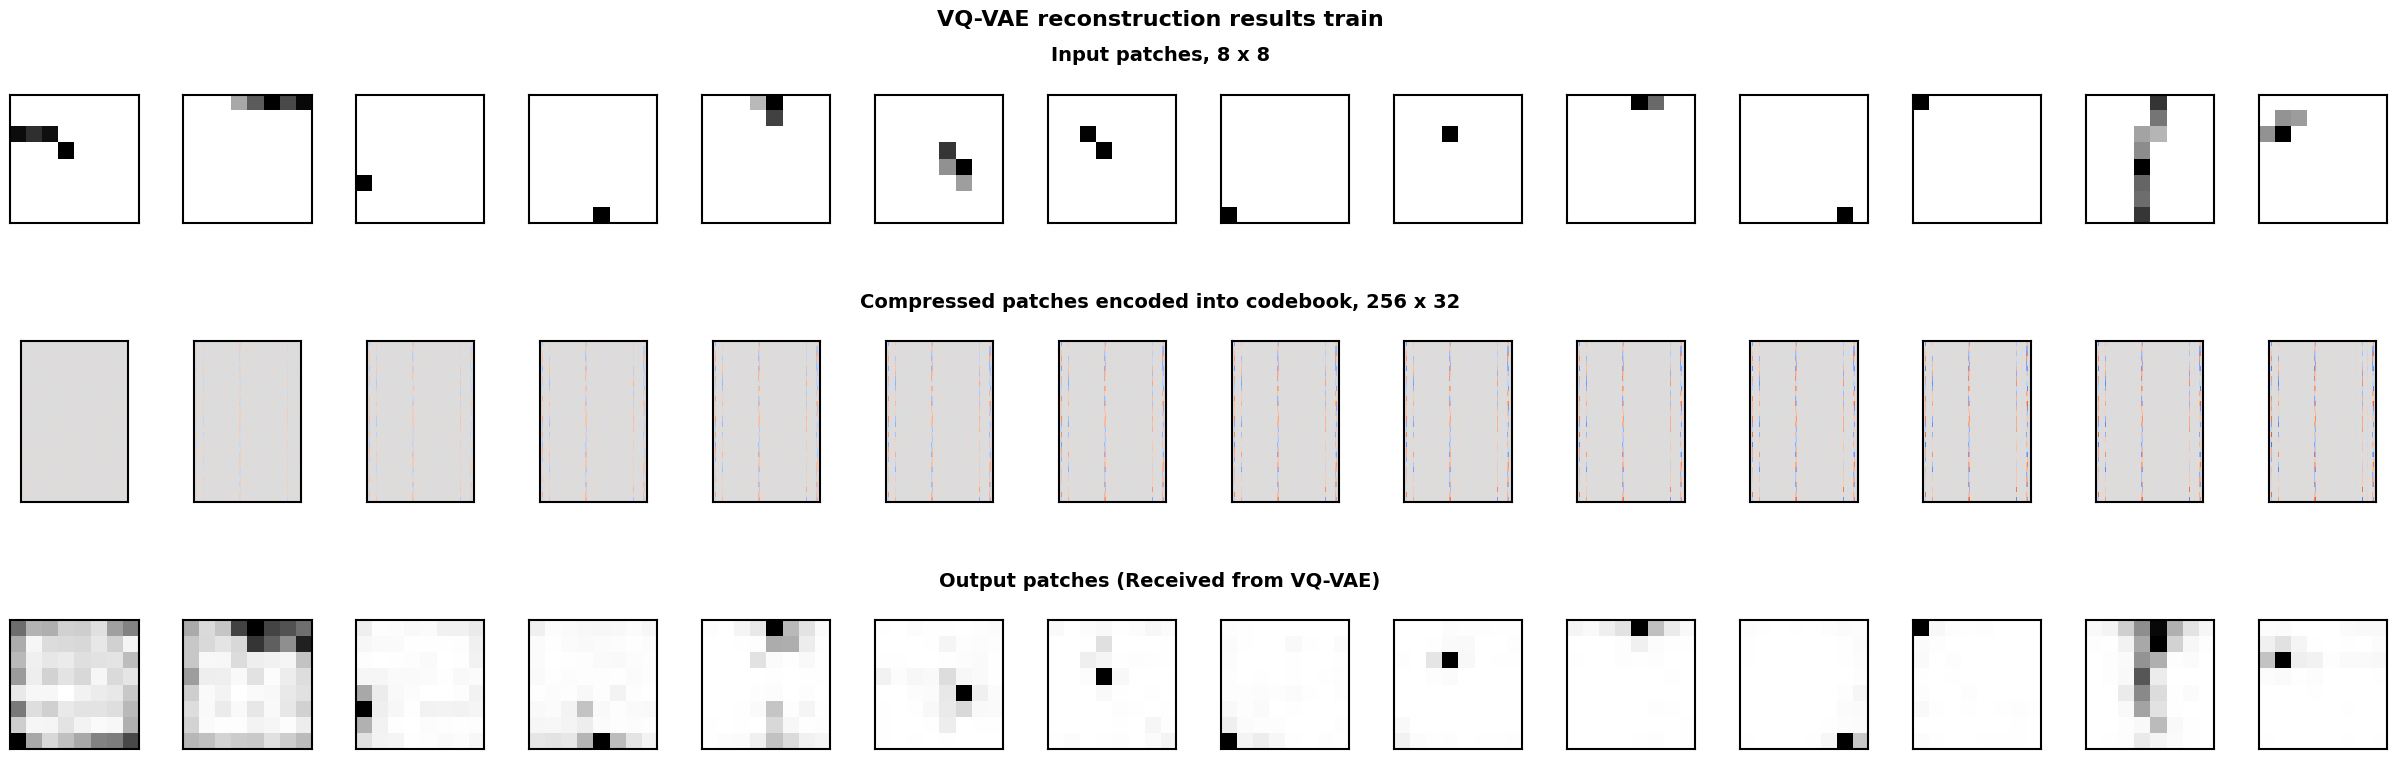

In [ ]:
patch_rows = [
    (patches_before_train, "Input patches, 8 x 8"),
    (
        patches_encodings_train, 
        f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
    ),
    (patches_after_train, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(patch_rows, "VQ-VAE reconstruction results train")

# NOTE: Some patches are blurry due to early collection in the epochs

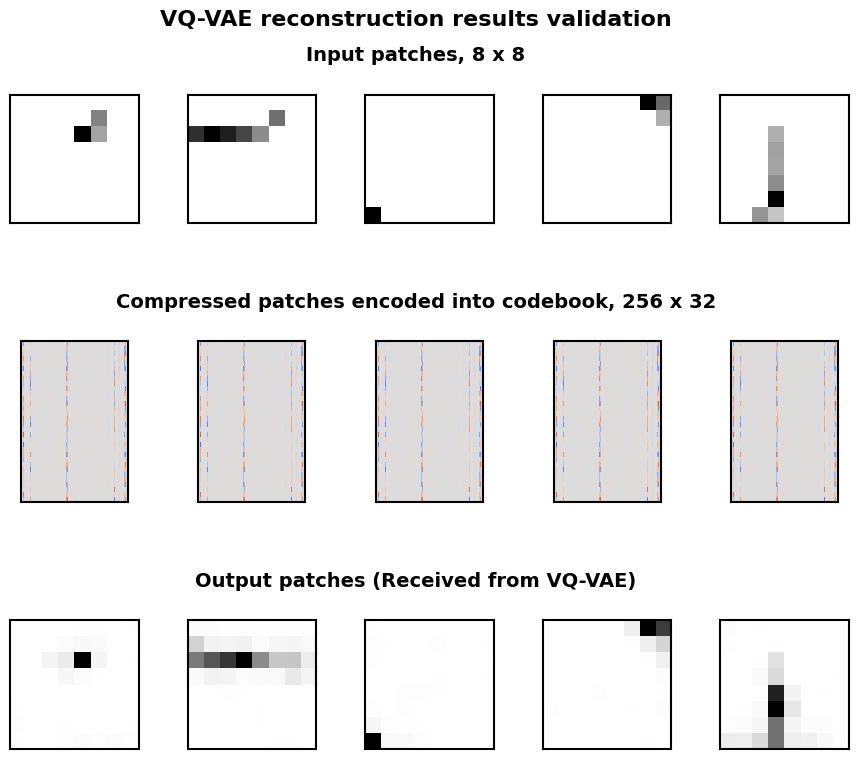

In [ ]:
patch_rows = [
    (patches_before_val, "Input patches, 8 x 8"),
    (patches_encodings_val, 
     f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
     ),
    (patches_after_val, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(
    patch_rows, 
    "VQ-VAE reconstruction results validation"
)

In [ ]:
# TODO
# Improve gradients
model_tool._display_gradients(model)

Showing model gradients
encoder.0.weight 0.1801801174879074
encoder.1.weight 0.02757946401834488
encoder.1.bias 0.02585607022047043
encoder.3.weight 1.2629598379135132
encoder.4.weight 0.022350633516907692
encoder.4.bias 0.02344999648630619
encoder.6.weight 1.1820393800735474
encoder.7.weight 0.012645089067518711
encoder.7.bias 0.016144931316375732
encoder.8.stack.0.res_block.1.weight 0.09293140470981598
encoder.8.stack.0.res_block.3.weight 0.0577714666724205
encoder.8.stack.1.res_block.1.weight 0.0899510458111763
encoder.8.stack.1.res_block.3.weight 0.061305344104766846
fc_encoder_input.layer.weight 0.039128340780735016
fc_encoder_input.layer.bias 0.012434862554073334
vq_layer.embedding.weight 0.0032644099555909634
fc_decoder_input.layer.weight 0.006320305168628693
fc_decoder_input.layer.bias 0.026611560955643654
decoder.0.weight 0.4524165689945221
decoder.1.weight 0.005984973628073931
decoder.1.bias 0.007174416445195675
decoder.2.stack.0.res_block.1.weight 0.05552585422992706
decoder

VQ VAE, BCE encoder average loss values over epochs


/home/paulius/vq_vae_experiments/helpers/data_tool.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


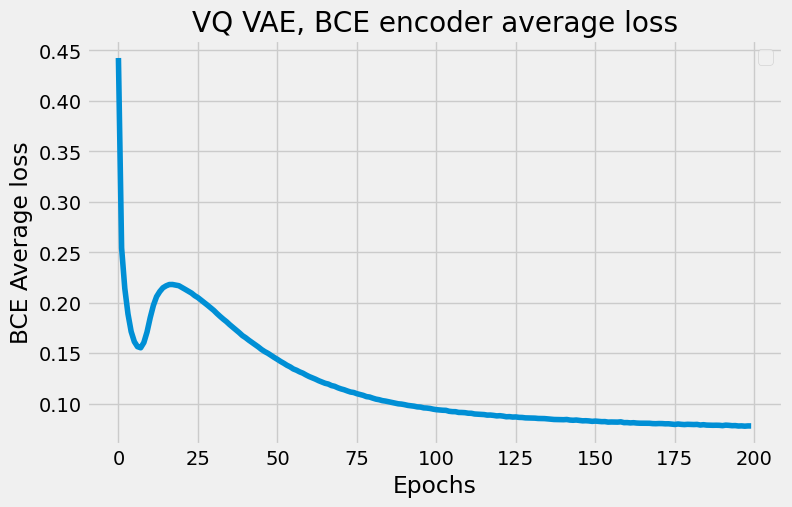

Saved VQ-VAE loss train data to csv
Saved VQ-VAE loss validation data to csv


In [ ]:
# display loss values
cms_plots.plot_curve(
    y_values=average_loss_train, 
    x_values=list(range(num_epochs)),
    y_title="BCE Average loss",
    title="VQ VAE, BCE encoder average loss",
    x_label="Epochs"
)

# Saving train loss data
data_csv = pd.DataFrame(
    {
        "vq_average_loss" : average_loss_train,
        "bce_average_train_loss" : average_loss_train_bce,
        "mse_average_train_loss" : average_loss_train_mse,
        "epochs" : list(range(num_epochs))        
    }
)
data_csv.to_csv("vqvae_average_train.csv",index=False)
print("Saved VQ-VAE loss train data to csv")

# Saving validation loss data
data_csv = pd.DataFrame(
    {
        "bce_average_val_loss" : average_loss_values_val,
        "mse_average_val_loss" : average_loss_valid_mse_val,
        "epochs" : list(range(num_epochs))        
    }
)
data_csv.to_csv("vqvae_average_val.csv",index=False)
print("Saved VQ-VAE loss validation data to csv")


In [ ]:
# Test set for testing using unseen data
model.load_state_dict(torch.load("vqvae.pth"))
model.eval()

bce_loss_values_test = []

patch_display_limit = 6
patches_after_test = []
patches_before_test = []
patches_encodings_test = [] # latent vector

bce_total_value = 0
perplexity_total = 0
test_set_size = len(test_loader)

for patch_test in test_loader:
    patch_test = patch_test.to(device)                     
    (
        recon_patch, 
        codebook_test, 
        z_q, 
        perplexity,
        _
    ) = model(patch_test)
    
    perplexity_total += perplexity.item()
    
    if len(patches_after_test) < patch_display_limit:
        patch_test_np = patch_test[0][0].cpu().detach().numpy()
        patches_before_test.append(patch_test_np)
        
        recon_patch_np = recon_patch[0][0].cpu().detach().numpy()
        patches_after_test.append(recon_patch_np)
        patches_encodings_test.append(
            model_tool._tensor_to_numpy(codebook_test)
        )
    
    # mse_loss = F.mse_loss(patch_test, recon_patch).item()
    bce_loss = F.binary_cross_entropy(
        patch_test, 
        recon_patch, 
        reduction="mean"
    ).cpu().detach().numpy().item()
    
    bce_total_value += bce_loss
    
bce_loss_average = bce_total_value / test_set_size
perplexity_average = perplexity_total / test_set_size

print(f"Based on test set (size = {test_set_size}), average BCE loss = {bce_loss_average:.5f}")
print(f"Based on test set (size = {test_set_size}), average codebook perplexity = {perplexity_average:.5f}/{num_embeddings}")

# saving
test_df_frame = pd.DataFrame(
    {
        "average_bce_loss_test" : [bce_loss_average],
        "average_perplexity_test" : [perplexity_average]
    }
)
test_df_frame.to_csv("vqvae_test_loss.csv")
print("Saved VQ-VAE test results")

RuntimeError: Error(s) in loading state_dict for VQVAE:
	Missing key(s) in state_dict: "fc_encoder_input.layer.weight", "fc_encoder_input.layer.bias", "fc_decoder_input.layer.weight", "fc_decoder_input.layer.bias". 

In [ ]:
len(patches_before_test)

6

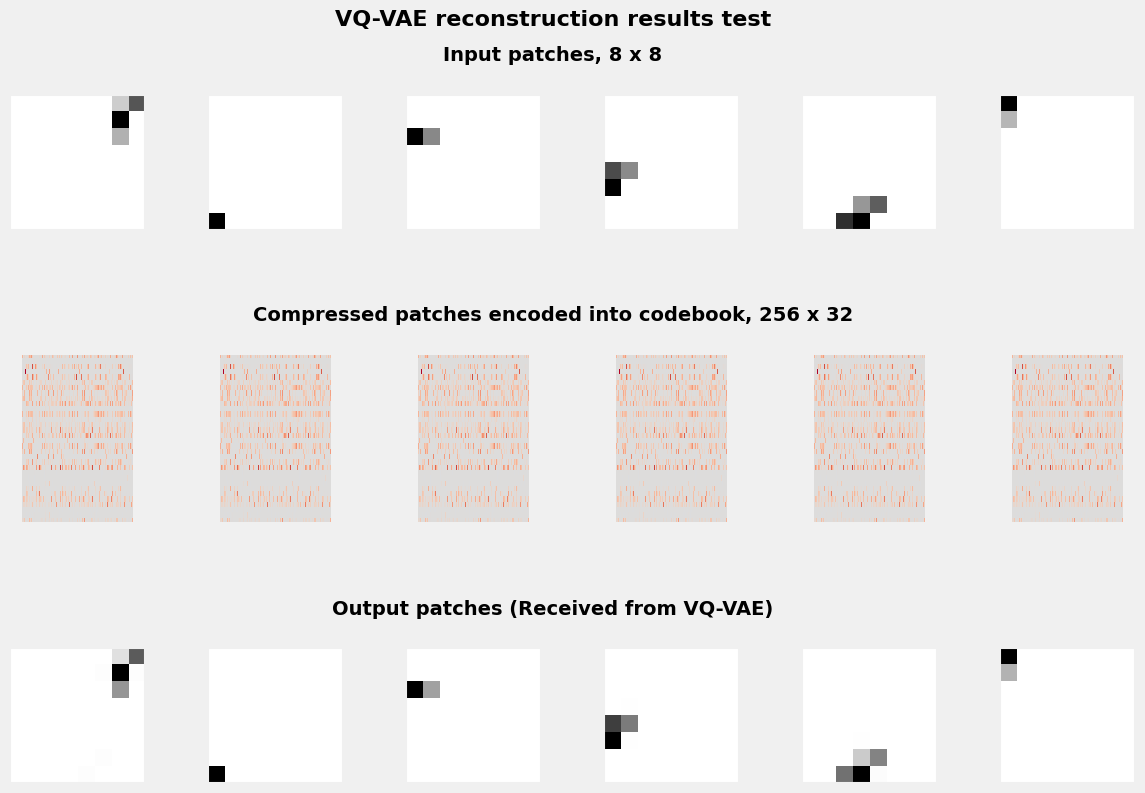

In [ ]:
# Test dataset plotting part
patch_rows = [
    (patches_before_test, "Input patches, 8 x 8"),
    (patches_encodings_test, f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"),
    (patches_after_test, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(patch_rows, "VQ-VAE reconstruction results test")

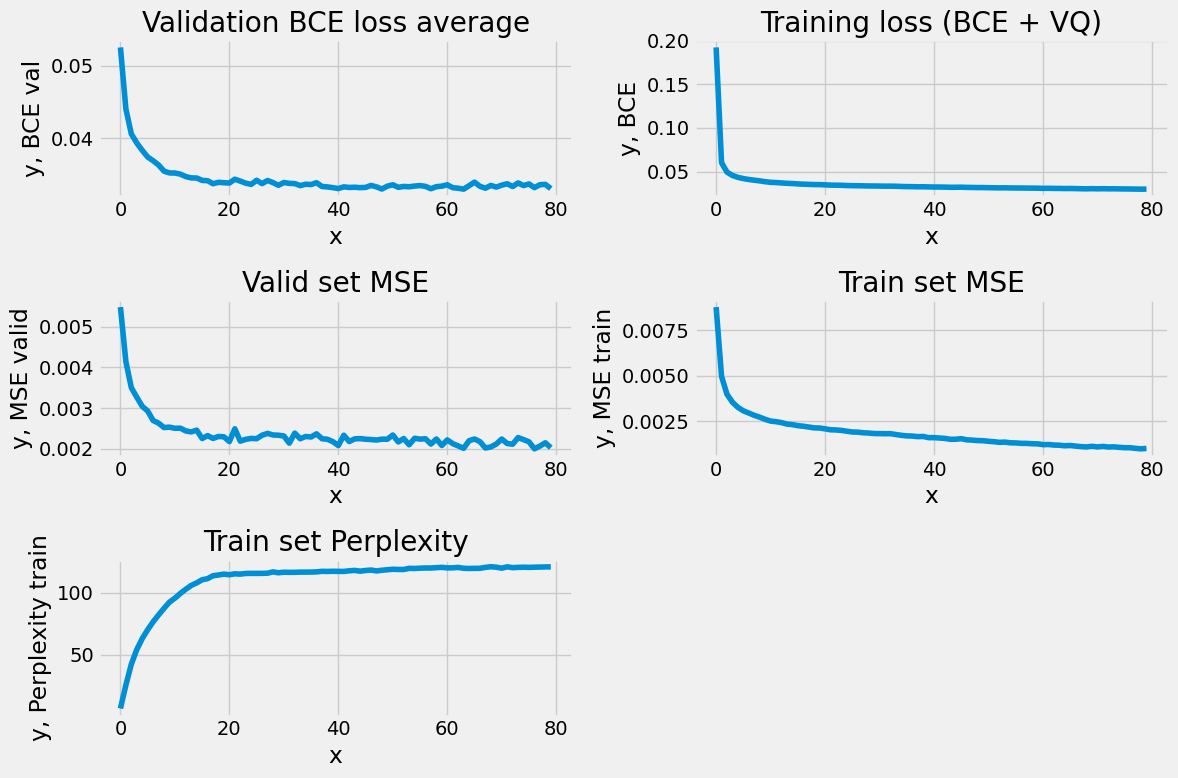

In [ ]:
values_to_plot = [
    (list(range(len(average_loss_values_val))), average_loss_values_val, "Validation BCE loss average", "BCE val"),
    (list(range(len(average_loss_train))), average_loss_train, "Training loss (BCE + VQ)", "BCE"),
    (list(range(len(average_loss_valid_mse_val))), average_loss_valid_mse_val, "Valid set MSE", "MSE valid"),
    (list(range(len(average_loss_train_mse))), average_loss_train_mse, "Train set MSE", "MSE train"),
    (list(range(len(average_perplexity_train))), average_perplexity_train, "Train set Perplexity", "Perplexity train"),
]

cms_plots.plot_curves(values_to_plot)
